In [499]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import random as rd
import math

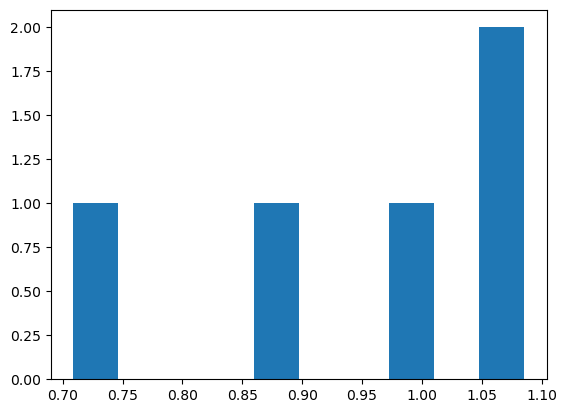

In [500]:
N_sample = 5
L_single = sp.stats.norm(loc=1, scale=0.2)
mock_sample = [rd.gauss(1, 0.2) for _ in range(N_sample)]
plt.hist(mock_sample)
plt.show()

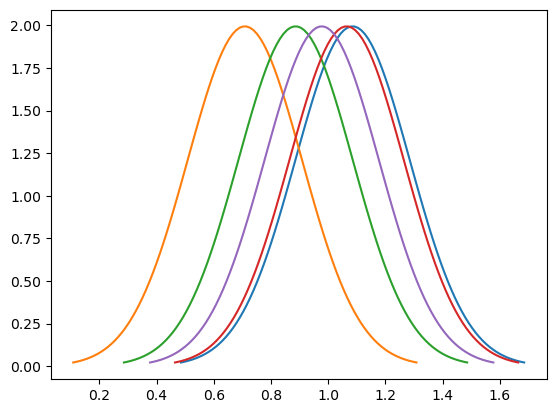

In [501]:
for elem in mock_sample[:10]: #plotting only the first 10 points not to mess the plot
    plt.plot(np.linspace(elem-0.6, elem+0.6, 100), np.ones(100)*sp.stats.norm(loc=elem, scale=0.2).pdf(np.linspace(elem-0.6, elem+0.6, 100)))

In [502]:
def L_tot(x): return math.prod(sp.stats.norm(loc=elem, scale=0.2).pdf(x) for elem in mock_sample)

mu grd 0.9444444444444444
mu MLE 0.9444551684135714


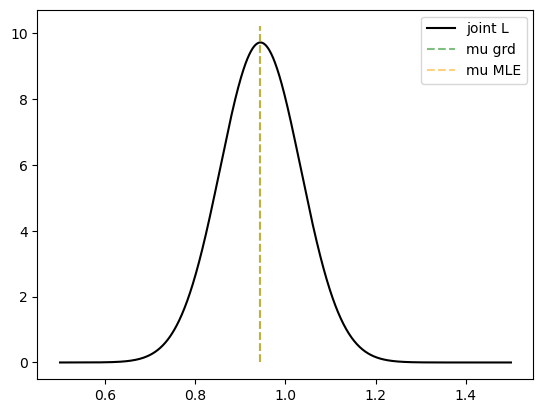

In [503]:
xx = np.linspace(0.5, 1.5, 1000)
mu_grd = xx[np.argmax(L_tot(xx))]
mu_MLE = np.mean(mock_sample)
print('mu grd', mu_grd)
print('mu MLE', mu_MLE)
plt.plot(xx, L_tot(xx), c='black', label='joint L')
plt.vlines(mu_grd, 0, np.max(L_tot(xx))*1.05, ls='dashed', color='green', label='mu grd', alpha=0.5)
plt.vlines(mu_MLE, 0, np.max(L_tot(xx))*1.05, ls='dashed', color='orange', label='mu MLE', alpha=0.5)
plt.legend()
plt.show()

# Part 2

In [504]:
FMEN = 1 / np.max(np.sqrt(np.diff(np.log(L_tot(xx)), n=2) / (xx[1]-xx[0])**2 * (-1))) #Fischer Matrix Error, Numerical
FMET = 0.2 / np.sqrt(N_sample)

In [505]:
print('FME theor', FMET)
print('FME numer', FMEN)

FME theor 0.08944271909999159
FME numer 0.08944271909369717


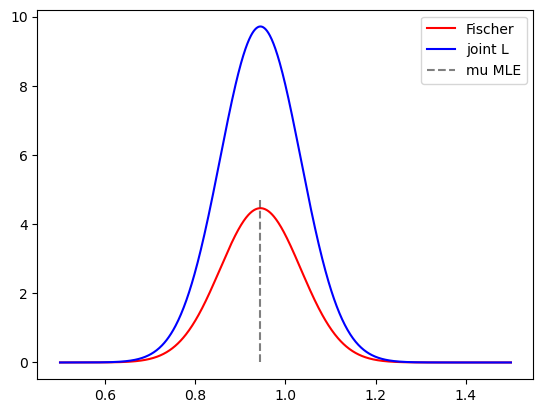

In [506]:
plt.plot(xx, sp.stats.norm.pdf(xx, loc=mu_MLE, scale=FMEN), c='red', label='Fischer')
plt.plot(xx, L_tot(xx), c='blue', label='joint L')
plt.vlines(mu_MLE, 0, np.max(sp.stats.norm.pdf(xx, loc=mu_MLE, scale=FMEN))*1.05, ls='dashed', color='black', label='mu MLE', alpha=0.5)
plt.legend()
plt.show()

# Part 3

In [507]:
std_sample = [rd.gauss(0.2, 0.05) for _ in range(N_sample)]
mock_sample_2 = [rd.gauss(1, 0.2) for _ in range(N_sample)]

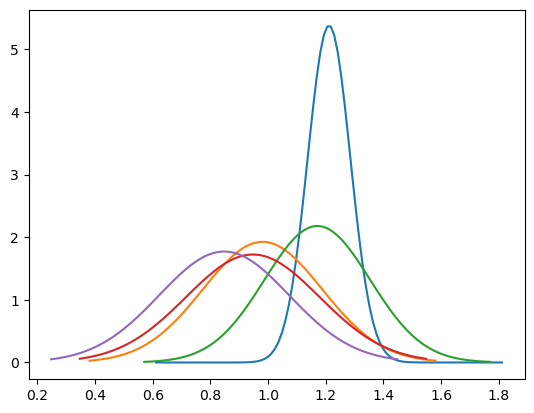

In [508]:
for i in range(len(mock_sample_2[:10])): #plotting only the first 10 points
    plt.plot(np.linspace(mock_sample_2[i]-0.6, mock_sample_2[i]+0.6, 100), np.ones(100)*sp.stats.norm(loc=mock_sample_2[i], scale=std_sample[i]).pdf(np.linspace(mock_sample_2[i]-0.6, mock_sample_2[i]+0.6, 100)))

In [509]:
def L_tot_2(x): return math.prod(sp.stats.norm(loc=mock_sample_2[i], scale=std_sample[i]).pdf(x) for i in range(len(mock_sample_2)))
mu_grd_2 = xx[np.argmax(L_tot_2(xx))]
std_sample_sq = np.zeros(N_sample)
for i in range(N_sample): std_sample_sq[i] = std_sample[i]**2
mu_MLE_2 = np.sum(mock_sample_2/std_sample_sq) / np.sum(1/std_sample_sq)

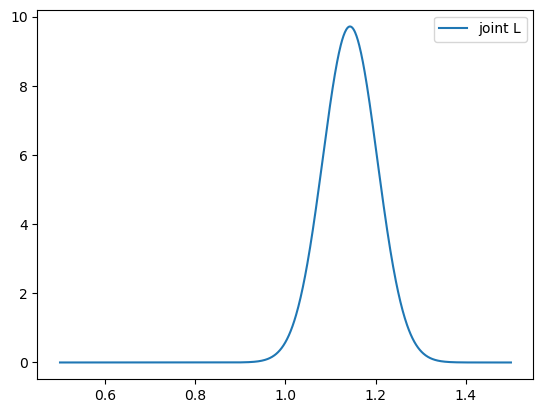

In [510]:
plt.plot(xx, L_tot_2(xx), label='joint L')
plt.legend()
plt.show()

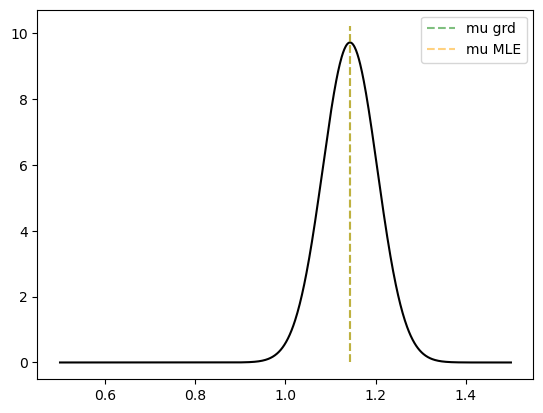

In [511]:
plt.plot(xx, L_tot_2(xx), c='black')
plt.vlines(mu_grd_2, 0, np.max(L_tot_2(xx))*1.05, ls='dashed', color='green', label='mu grd', alpha=0.5)
plt.vlines(mu_MLE_2, 0, np.max(L_tot_2(xx))*1.05, ls='dashed', color='orange', label='mu MLE', alpha=0.5)
plt.legend()
plt.show()

In [512]:
FMEN_2 = 1 / np.max(np.sqrt(np.diff(np.log(L_tot_2(xx)), n=2) / (xx[1]-xx[0])**2 * (-1))) #Fischer Matrix Error, Numerical
FMET_2 = 1 / np.sqrt(np.sum(1/std_sample_sq))

In [513]:
print('FME theor', FMET_2)
print('FME numer', FMEN_2)

FME theor 0.06043159124590668
FME numer 0.06043159124080176


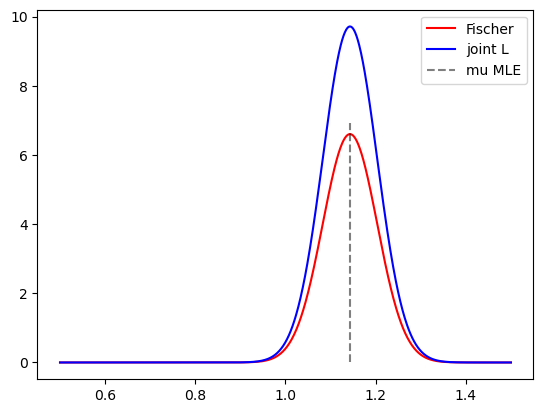

In [514]:
plt.plot(xx, sp.stats.norm.pdf(xx, loc=mu_MLE_2, scale=FMEN_2), c='red', label='Fischer')
plt.plot(xx, L_tot_2(xx), c='blue', label='joint L')
plt.vlines(mu_MLE_2, 0, np.max(sp.stats.norm.pdf(xx, loc=mu_MLE_2, scale=FMEN_2))*1.05, ls='dashed', color='black', label='mu MLE', alpha=0.5)
plt.legend()
plt.show()